Importing libraries

In [ ]:
import matplotlib.pyplot as plt
import tensorflow.keras as K
import tensorflow as tf
from keras.callbacks import ModelCheckpoint
from keras.datasets import cifar10
from keras.layers import Dense,Dropout, Flatten, Conv2D, MaxPooling2D, Layer, Lambda, BatchNormalization, GlobalAveragePooling2D

In [ ]:
def preprocess_data(X, Y):
    """
    Pre-processes the data for the model

        :param X: numpy.ndarray of shape (m, 32, 32, 3)
            containing the CIFAR 10 data, where m is the
            number of data points

        :param Y: numpy.ndarray of shape (m,) containing
            the CIFAR 10 labels for X

        :returns: X_p, Y_p
    """
    X_p = K.applications.densenet.preprocess_input(X)

    # encode to one-hot
    Y_p = K.utils.to_categorical(Y, 10)
    return X_p, Y_p


In [ ]:
CALLBACKS = []
'''MODEL_PATH = '/kaggle/working/cifar10.h5'''
optimizer = K.optimizers.Adam()

# load cifar 10
(x_train, y_train), (x_test, y_test) = K.datasets.cifar10.load_data()


170498071/170498071 [==============================] - 7s 0us/step


In [ ]:
(X_train, Y_train), (X_test, Y_test) = K.datasets.cifar10.load_data()

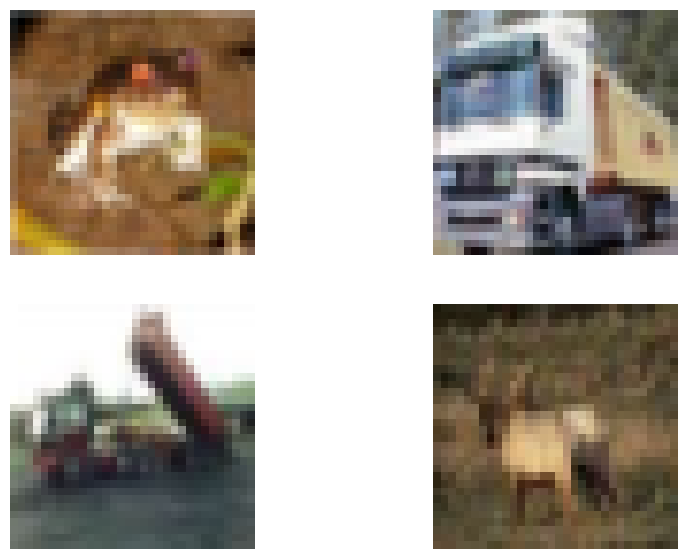

In [ ]:
# Visilations
plt.figure(figsize = (10,7))
plt.subplot(221)

# equivalent but more general
ax1 = plt.subplot(2, 2, 1)
ax1.imshow(x_train[0])
ax1.axis('off')

# add a subplot with no frame
ax2 = plt.subplot(222, frameon=False)
ax2.imshow(x_train[1])
ax2.axis('off')

# add a polar subplot
ax3 = plt.subplot(223)
ax3.imshow(x_train[2])
ax3.axis('off')

# add a red subplot that shares the x-axis with ax1
ax4 = plt.subplot(224)
ax4.imshow(x_train[3])
ax4.axis('off')
plt.show()

In [ ]:
# pre-procces data
x_train, y_train = preprocess_data(x_train, y_train)
x_test, y_test = preprocess_data(x_test, y_test)

# input tensor
inputs = K.Input(shape=(32, 32, 3))

# upscale layer
upscale = K.layers.Lambda(lambda x: tf.image.resize_with_pad(x,
                                                                  160,
                                                                  160,
                                                                  method=tf.image.ResizeMethod.BILINEAR))(inputs)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Model DenseNet121

In [ ]:
import keras
densecifar = keras.models.load_model('/content/drive/MyDrive/densecifar.keras',safe_mode=False)

In [ ]:
densecifar.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 32, 32, 3)]          0         []                            
                                                                                                  
 lambda (Lambda)             (None, 160, 160, 3)          0         ['input_1[0][0]']             
                                                                                                  
 zero_padding2d (ZeroPaddin  (None, 166, 166, 3)          0         ['lambda[0][0]']              
 g2D)                                                                                             
                                                                                                  
 conv1/conv (Conv2D)         (None, 80, 80, 64)           9408      ['zero_padding2d[0][0]']  

In [ ]:
pip install shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 538.2/538.2 kB 3.5 MB/s eta 0:00:00


Partition SHAP

In [ ]:
import numpy as np
def f(x):
    temp=x.copy()
    p=densecifar(temp)
    class_name=np.argmax(p,axis=1)
    #return class_name
    return p
class_name = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

In [ ]:
import shap
masker = shap.maskers.Image("blur(28,28)", x_train[0].shape)
explainer = shap.Explainer(f, masker,output_names=class_name)

In [ ]:
part_shap_values=explainer(x_test[0:100],max_evals=5000,batch_size=50,outputs=shap.Explanation.argsort.flip[:1])

  0%|          | 0/4998 [00:00<?, ?it/s]

PartitionExplainer explainer:   1%|          | 1/100 [00:00<?, ?it/s]

  0%|          | 0/4998 [00:00<?, ?it/s]

PartitionExplainer explainer:   3%|▎         | 3/100 [01:25<20:41, 12.80s/it]

  0%|          | 0/4998 [00:00<?, ?it/s]

...

PartitionExplainer explainer:  99%|█████████▉| 99/100 [42:54<00:25, 25.89s/it]

  0%|          | 0/4998 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 100/100 [43:19<00:00, 25.85s/it]

  0%|          | 0/4998 [00:00<?, ?it/s]

PartitionExplainer explainer: 101it [43:45, 26.26s/it]


In [ ]:
partvec=[]
for k in range(100):
  rw=[]
  r1=[]
  for i in range(32):
    r1=part_shap_values[k][i]
    for j in range(32):
        rw.append(r1.values[j][0][0])
  partvec.append(rw)

partvec_pos=[]
for k in range(100):
  partition_score_zero=[0 if i<0 else i for i in partvec[k]]
  partvec_pos.append(partition_score_zero)

Gradient SHAP

In [ ]:
import shap
# since we have two inputs we pass a list of inputs to the explainer
e = shap.GradientExplainer(densecifar,x_train)
# we explain the model's predictions on the first three samples of the test set
shap_values = e.shap_values(x_test[:100])

/usr/local/lib/python3.10/dist-packages/keras/src/backend.py:452: UserWarning: `tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.
  warnings.warn(


In [ ]:
shapgradvec=[]
for k in range(100):
  rw=[]
  r1=[]
  for i in range(32):
    r1=shap_values[k][i]
    for j in range(32):
        rw.append(r1[j][0][0])
  shapgradvec.append(rw)

In [ ]:
shapgradvec_pos=[] #only positive scores
#deepvec_pos=[] #only positive scores
for k in range(100):
  shapgrad_score_zero=[0 if i<0 else i for i in shapgradvec[k]]
  shapgradvec_pos.append(shapgrad_score_zero)
  #deepshap_score_zero= [0 if i<0 else i for i in deepvec[k]]
  #deepvec_pos.append(deepshap_score_zero)

In [ ]:
pip install tf_keras_vis

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 967.1 kB/s eta 0:00:00


In [ ]:
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear

replace2linear = ReplaceToLinear()

# Instead of using the ReplaceToLinear instance above,
# you can also define the function from scratch as follows:
def model_modifier_function(cloned_model):
    cloned_model.layers[-1].activation = tf.keras.activations.linear

In [ ]:
from tf_keras_vis.utils.scores import CategoricalScore

#score = CategoricalScore([0,1,2,3,4,5,6,7,8,9])

# Instead of using CategoricalScore object,
# you can also define the function from scratch as follows:
def score_function(output):
    # The `output` variable refers to the output of the model,
    # so, in this case, `output` shape is `(3, 1000)` i.e., (samples, classes).
    return (output[:,])

In [ ]:
import numpy as np

In [ ]:
X = np.array(X_train,dtype="float32")
#x_test = np.array(x_test,dtype="float32")

In [ ]:
X_val= np.array(X_test,dtype="float32")

GradCAM

In [ ]:
from matplotlib import cm
from tf_keras_vis.gradcam import Gradcam

# Create Gradcam object
gradcam = Gradcam(densecifar,
                  model_modifier=replace2linear,
                  clone=True)

# Generate heatmap with GradCAM
cam = gradcam(score_function,
              X_val[0:100],
              penultimate_layer=-1)

## Since v0.6.0, calling `normalize()` is NOT necessary.
# cam = normalize(cam)
# Render
'''for i in range(5):
  heatmap = np.uint8(cm.jet(cam[i])[..., :5] * 255)
  label_index = np.argmax(y_test[i+50])
  plt.title(class_name[label_index])
  plt.imshow((X_val[i+50]*255).astype(np.uint8))
  plt.imshow(heatmap, cmap='jet', alpha=0.5)
  plt.axis('off')
  plt.show()'''

"for i in range(5):\n  heatmap = np.uint8(cm.jet(cam[i])[..., :5] * 255)\n  label_index = np.argmax(y_test[i+50])\n  plt.title(class_name[label_index])\n  plt.imshow((X_val[i+50]*255).astype(np.uint8))\n  plt.imshow(heatmap, cmap='jet', alpha=0.5)\n  plt.axis('off')\n  plt.show()"

In [ ]:
gradvec=[]
for k in range(100):
  rw=[]
  r1=[]
  for i in range(32):
    r1=cam[k][i]
    for j in range(32):
      rw.append(r1[j])
  gradvec.append(rw)

GradCAM++

In [ ]:
from tf_keras_vis.gradcam_plus_plus import GradcamPlusPlus

# Create GradCAM++ object
gradcampp = GradcamPlusPlus(densecifar,
                          model_modifier=replace2linear,
                          clone=True)

# Generate heatmap with GradCAM++
campp = gradcampp(score_function,
              X_val[0:100],
              penultimate_layer=-1)

## Since v0.6.0, calling `normalize()` is NOT necessary.
# cam = normalize(cam)

# Render
'''for i in range(5):
  heatmap = np.uint8(cm.jet(campp[i])[..., :5] * 255)
  label_index = np.argmax(y_test[i+50])
  plt.title(class_name[label_index])
  plt.imshow((X_val[i+50]*255).astype(np.uint8))
  plt.imshow(heatmap, cmap='jet', alpha=0.5)
  plt.axis('off')
  plt.show()'''

"for i in range(5):\n  heatmap = np.uint8(cm.jet(campp[i])[..., :5] * 255)\n  label_index = np.argmax(y_test[i+50])\n  plt.title(class_name[label_index])\n  plt.imshow((X_val[i+50]*255).astype(np.uint8))\n  plt.imshow(heatmap, cmap='jet', alpha=0.5)\n  plt.axis('off')\n  plt.show()"

In [ ]:
gradppvec=[]
for k in range(100):
  rw=[]
  r1=[]
  for i in range(32):
    r1=campp[k][i]
    for j in range(32):
      rw.append(r1[j])
  gradppvec.append(rw)

### Metric Part

### MC+BC Metric


In [ ]:
#argsort descending order - pixel position
shapgradvec_pixel=[]
partvec_pixel=[]
gradvec_pixel=[]
gradppvec_pixel=[]
for k in range(100): #gradientshap
  rw_temp=shapgradvec_pos[k]
  revid=np.argsort(rw_temp)[::-1][:1024]
  shapgradvec_pixel.append(revid)

for k in range(100): #partition
  rw_temp=partvec_pos[k]
  revid=np.argsort(rw_temp)[::-1][:1024]
  partvec_pixel.append(revid)

for k in range(100): #gradcam
  rw_temp=gradvec[k]
  revid=np.argsort(rw_temp)[::-1][:1024]
  gradvec_pixel.append(revid)

for k in range(100): #gradcam++
  rw_temp=gradppvec[k]
  revid=np.argsort(rw_temp)[::-1][:1024]
  gradppvec_pixel.append(revid)

In [ ]:
import math
import numpy as np
def multiplefull(a,b,c,d): #a-gradshap, b-partition, c-gradcam, d-gradcam++
  ans=[]
  for k in range(100):
    temp=[]
    r12=np.corrcoef(a[k],b[k])
    r13=np.corrcoef(a[k],c[k])
    r14=np.corrcoef(a[k],d[k])
    r23=np.corrcoef(b[k],c[k])
    r24=np.corrcoef(b[k],d[k])
    r34=np.corrcoef(c[k],d[k])
    #print(r13[0][1],r34[0][1])
    r12_3=(r12[0][1]-(r13[0][1]*r23[0][1]))/(math.sqrt((1-r13[0][1]*r13[0][1])*(1-r23[0][1]*r23[0][1])))
    r14_3=(r14[0][1]-(r13[0][1]*r34[0][1]))/(math.sqrt((1-r13[0][1]*r13[0][1])*(1-r34[0][1]*r34[0][1])))
    r14_2=(r14[0][1]-(r12[0][1]*r24[0][1]))/(math.sqrt((1-r12[0][1]*r12[0][1])*(1-r24[0][1]*r24[0][1])))
    r24_3=(r24[0][1]-(r23[0][1]*r34[0][1]))/(math.sqrt((1-r23[0][1]*r23[0][1])*(1-r34[0][1]*r34[0][1])))
    r13_2=(r13[0][1]-(r12[0][1]*r23[0][1]))/(math.sqrt((1-r12[0][1]*r12[0][1])*(1-r23[0][1]*r23[0][1])))
    r34_2=(r34[0][1]-(r23[0][1]*r24[0][1]))/(math.sqrt((1-r23[0][1]*r23[0][1])*(1-r24[0][1]*r24[0][1])))
    #print(r14[0][1])
    #print((r13[0][1]*r34[0][1]))
    #print(math.sqrt((1-r13[0][1]*r13[0][1])*(1-r34[0][1]*r34[0][1])))
    #print(r12_3,r14_3,r14_2,r24_3,r13_2,r34_2)
    r12_34=(r12_3-r14_3*r24_3)/(math.sqrt((1-r14_3*r14_3)*(1-r24_3*r24_3)))
    r13_24=(r13_2-r14_2*r34_2)/(math.sqrt((1-r14_2*r14_2)*(1-r34_2*r34_2)))
    r14_23=(r14_2-r13_2*r34_2)/(math.sqrt((1-r13_2*r13_2)*(1-r34_2*r34_2)))
    #print(r12_34,r13_24,r14_23)
    R1_234=math.sqrt(1-(1-r14[0][1]*r14[0][1])*(1-r12_3*r12_3)*(1-r12_34*r12_34))
    R2_134=math.sqrt(1-(1-r24[0][1]*r24[0][1])*(1-r12_3*r12_3)*(1-r12_34*r12_34))
    R3_124=math.sqrt(1-(1-r34[0][1]*r34[0][1])*(1-r13_2*r13_2)*(1-r13_24*r13_24))
    R4_123=math.sqrt(1-(1-r34[0][1]*r34[0][1])*(1-r14_2*r14_2)*(1-r14_23*r14_23))
    #print(R1_234,R2_134,R3_124,R4_123)
    temp.append(R1_234)
    temp.append(R2_134)
    temp.append(R3_124)
    temp.append(R4_123)
    ans.append(temp)
  return ans

In [ ]:
out=multiplefull(shapgradvec_pixel,partvec_pixel,gradvec_pixel,gradppvec_pixel)
out

[[0.08763035933104446,
  0.06899874805898107,
  0.05348054734966306,
  0.09461355400547315],
 [0.09092922162560421,
  0.08537782436446423,
  0.21961311410998682,
  0.20569163588050257],
 [0.19934866481058103,
  0.1654074819706503,
  0.43561425587615715,
  0.34738873615356164],
 [0.29302514233222354,
  0.295048308394985,
  0.2570112788720788,
  0.21779482621097623],
 [0.09399623059916472,
  0.10085121854479694,
  0.2833076544300639,
  0.2982181710501255],
 [0.08129113400017526,
  0.08186317575366588,
  0.10298959479756097,
  0.09251638556051091],
 [0.39272253691938985,
  0.39172169767770515,
  0.25146695883173653,
  0.2563304278998867],
 [0.09267299856340921,
  0.09209799796207392,
  0.09917174829115298,
  0.10785231788785472],
 [0.06908993376817575,
  0.07730416827065553,
  0.24739981413986986,
  0.2484563054629637],
 [0.14647301276301306,
  0.13939947949745532,
  0.08564895918554966,
  0.07334268171731285],
 [0.25982206582936473,
  0.24274052331608212,
  0.2755981289709445,
  0.284847

In [ ]:
iout=[]
for i in range(100):
  x=np.argsort(out[i])[::-1][:1024]
  iout.append(x)
iout

[array([3, 0, 1, 2]),
 array([2, 3, 0, 1]),
 array([2, 3, 0, 1]),
 array([1, 0, 2, 3]),
 array([3, 2, 1, 0]),
 array([2, 3, 1, 0]),
 array([0, 1, 3, 2]),
 array([3, 2, 0, 1]),
 array([3, 2, 1, 0]),
 array([0, 1, 2, 3]),
 array([3, 2, 0, 1]),
 array([0, 3, 1, 2]),
 array([3, 0, 2, 1]),
 array([3, 2, 1, 0]),
 array([0, 1, 2, 3]),
 array([1, 0, 3, 2]),
 array([1, 0, 2, 3]),
 array([3, 2, 1, 0]),
 array([1, 0, 2, 3]),
 array([3, 2, 0, 1]),
 array([1, 0, 2, 3]),
 array([3, 1, 2, 0]),
 array([3, 0, 1, 2]),
 array([3, 2, 0, 1]),
 array([0, 1, 3, 2]),
 array([1, 0, 2, 3]),
 array([3, 2, 1, 0]),
 array([2, 3, 1, 0]),
 array([2, 3, 0, 1]),
 array([3, 2, 0, 1]),
 array([1, 0, 2, 3]),
 array([0, 1, 3, 2]),
 array([3, 0, 2, 1]),
 array([3, 2, 1, 0]),
 array([0, 1, 2, 3]),
 array([2, 3, 1, 0]),
 array([2, 3, 0, 1]),
 array([2, 0, 3, 1]),
 array([1, 3, 2, 0]),
 array([1, 0, 3, 2]),
 array([1, 0, 2, 3]),
 array([3, 2, 1, 0]),
 array([2, 3, 0, 1]),
 array([1, 3, 2, 0]),
 array([3, 2, 1, 0]),
 array([3,

In [ ]:
#making 0as 1, 1as 2 ...
iout1=[]
for i in range(100):
  temp=iout[i]
  t=[x+1 for x in temp]
  iout1.append(t)
iout1

[[4, 1, 2, 3],
 [3, 4, 1, 2],
 [3, 4, 1, 2],
 [2, 1, 3, 4],
 [4, 3, 2, 1],
 [3, 4, 2, 1],
 [1, 2, 4, 3],
 [4, 3, 1, 2],
 [4, 3, 2, 1],
 [1, 2, 3, 4],
 [4, 3, 1, 2],
 [1, 4, 2, 3],
 [4, 1, 3, 2],
 [4, 3, 2, 1],
 [1, 2, 3, 4],
 [2, 1, 4, 3],
 [2, 1, 3, 4],
 [4, 3, 2, 1],
 [2, 1, 3, 4],
 [4, 3, 1, 2],
 [2, 1, 3, 4],
 [4, 2, 3, 1],
 [4, 1, 2, 3],
 [4, 3, 1, 2],
 [1, 2, 4, 3],
 [2, 1, 3, 4],
 [4, 3, 2, 1],
 [3, 4, 2, 1],
 [3, 4, 1, 2],
 [4, 3, 1, 2],
 [2, 1, 3, 4],
 [1, 2, 4, 3],
 [4, 1, 3, 2],
 [4, 3, 2, 1],
 [1, 2, 3, 4],
 [3, 4, 2, 1],
 [3, 4, 1, 2],
 [3, 1, 4, 2],
 [2, 4, 3, 1],
 [2, 1, 4, 3],
 [2, 1, 3, 4],
 [4, 3, 2, 1],
 [3, 4, 1, 2],
 [2, 4, 3, 1],
 [4, 3, 2, 1],
 [4, 3, 2, 1],
 [4, 3, 1, 2],
 [2, 1, 4, 3],
 [3, 2, 4, 1],
 [1, 2, 4, 3],
 [2, 1, 4, 3],
 [4, 3, 2, 1],
 [3, 4, 1, 2],
 [4, 3, 1, 2],
 [4, 3, 1, 2],
 [4, 3, 1, 2],
 [4, 1, 3, 2],
 [4, 3, 2, 1],
 [4, 3, 1, 2],
 [4, 1, 3, 2],
 [4, 3, 2, 1],
 [3, 4, 2, 1],
 [4, 3, 1, 2],
 [3, 1, 2, 4],
 [4, 1, 2, 3],
 [2, 1, 4, 3],
 [3, 4, 2,

In [ ]:
def borda_count(votes):
    num_candidates = len(votes[0])
    scores = {candidate: 0 for candidate in range(1, num_candidates + 1)}

    for ballot in votes:
        for index, candidate in enumerate(ballot):
            scores[candidate] += num_candidates - index - 1

    sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return sorted_scores

In [ ]:
ballots=iout1
result = borda_count(ballots)
print("Borda Count Result:")
for candidate, score in result:
    print(f"Candidate {candidate}: {score} points")

Borda Count Result:
Candidate 4: 186 points
Candidate 3: 168 points
Candidate 2: 125 points
Candidate 1: 121 points


In [ ]:
#final ranking - Multiple correlation
#based borda count ranking
borda_rank=[]
for candidate, score in result:
    borda_rank.append(candidate)
borda_rank

[4, 3, 2, 1]

### Borda Count (BC) Metric


In [ ]:
shapgradpixel1 = [x+1 for x in shapgradvec_pixel]
partpixel1=[x+1 for x in partvec_pixel]
gradpixel1=[x+1 for x in gradvec_pixel]
gradpppixel1=[x+1 for x in gradppvec_pixel]

In [ ]:
def calculateborda(a,b,c,d):
  bordarank=[]
  for k in range(100):
    ballot=[]
    ballot.append(a[k])
    ballot.append(b[k])
    ballot.append(c[k])
    ballot.append(d[k])

    print(ballot)
    res=borda_count(ballot)
    borda_rank=[]
    for candidate, score in res:
      borda_rank.append(candidate) #single instance
    bordarank.append(borda_rank)
  return bordarank #for 100 samples

In [ ]:
bordarank=calculateborda(shapgradpixel1,partpixel1,gradpixel1,gradpppixel1)
bordarank

[array([493, 525, 755, ..., 562, 561,   1]), array([284, 283, 425, ..., 891, 392, 952]), array([ 265,  233,  264, ..., 1023,  992, 1024]), array([745, 265, 266, ...,  64,  31,  32])]
[array([943, 910, 880, ..., 750, 752, 512]), array([456, 455, 720, ..., 261, 262, 443]), array([ 265,  233,  266, ..., 1009, 1008,  993]), array([497, 529, 496, ...,   2,  33,   1])]
[array([404, 217, 266, ..., 609, 604,   1]), array([ 232,  231,  454, ...,  275,  276, 1024]), array([280, 279, 278, ..., 929, 961, 993]), array([529, 497, 530, ...,  33,   2,   1])]
[array([585, 616, 683, ..., 595, 591, 512]), array([530, 529, 559, ..., 625, 614, 512]), array([280, 279, 265, ..., 929, 961, 993]), array([521, 522, 553, ...,   2,  33,   1])]
[array([816, 720, 966, ..., 575, 573,   1]), array([344, 343, 555, ..., 539, 540,   1]), array([745, 777, 746, ...,   2,  33,   1]), array([760, 759, 758, ...,   2,  33,   1])]
[array([589, 616, 776, ..., 718, 717,   1]), array([401, 501, 502, ..., 861, 858,   1]), array([2

[[299,
  280,
  276,
  300,
  310,
  334,
  333,
  274,
  281,
  338,
  363,
  335,
  371,
  364,
  332,
  298,
  339,
  308,
  312,
  393,
  247,
  342,
  232,
  302,
  273,
  341,
  215,
  275,
  268,
  278,
  297,
  265,
  431,
  331,
  277,
  309,
  336,
  340,
  301,
  238,
  307,
  231,
  269,
  267,
  649,
  270,
  279,
  304,
  242,
  553,
  311,
  245,
  283,
  206,
  241,
  329,
  337,
  400,
  328,
  715,
  271,
  460,
  432,
  330,
  686,
  272,
  183,
  457,
  305,
  685,
  205,
  306,
  343,
  203,
  359,
  493,
  522,
  344,
  263,
  313,
  492,
  199,
  746,
  282,
  303,
  266,
  284,
  209,
  372,
  327,
  234,
  347,
  246,
  377,
  438,
  264,
  212,
  243,
  687,
  619,
  200,
  248,
  345,
  437,
  136,
  494,
  169,
  463,
  718,
  326,
  554,
  586,
  778,
  618,
  237,
  314,
  147,
  712,
  285,
  213,
  260,
  744,
  394,
  104,
  780,
  557,
  233,
  425,
  184,
  356,
  175,
  587,
  262,
  760,
  228,
  525,
  182,
  292,
  421,
  235,
  656,
  714,
  395,

In [ ]:
def bordarankcorr(a,b,c,d,borda):
  bordarank_allimages=[]
  for k in range(100):
    temp=[]

    a_borda=np.corrcoef(a[k],borda[k]) #gradshap vs borda
    b_borda=np.corrcoef(b[k],borda[k]) #part vs borda
    c_borda=np.corrcoef(c[k],borda[k]) #grad vs borda
    d_borda=np.corrcoef(d[k],borda[k]) #gradpp vs borda

    temp.append(a_borda[0][1])
    temp.append(b_borda[0][1])
    temp.append(c_borda[0][1])
    temp.append(d_borda[0][1])
    t=np.argsort(temp)[::-1][:4]
    bordarank_allimages.append(t)
  return bordarank_allimages

In [ ]:
borda_allimages=bordarankcorr(shapgradpixel1,partpixel1,gradpixel1,gradpppixel1,bordarank)
borda_allimages

[array([2, 1, 0, 3]),
 array([2, 0, 1, 3]),
 array([2, 0, 1, 3]),
 array([2, 0, 1, 3]),
 array([3, 2, 1, 0]),
 array([0, 1, 3, 2]),
 array([1, 0, 3, 2]),
 array([3, 2, 0, 1]),
 array([1, 2, 0, 3]),
 array([2, 0, 1, 3]),
 array([2, 1, 0, 3]),
 array([2, 1, 3, 0]),
 array([2, 3, 0, 1]),
 array([3, 0, 1, 2]),
 array([2, 1, 0, 3]),
 array([3, 1, 2, 0]),
 array([3, 2, 0, 1]),
 array([0, 3, 1, 2]),
 array([2, 0, 3, 1]),
 array([3, 2, 1, 0]),
 array([2, 1, 0, 3]),
 array([2, 1, 0, 3]),
 array([2, 0, 1, 3]),
 array([2, 1, 0, 3]),
 array([3, 1, 2, 0]),
 array([2, 0, 1, 3]),
 array([3, 2, 1, 0]),
 array([2, 0, 1, 3]),
 array([2, 1, 0, 3]),
 array([2, 1, 0, 3]),
 array([2, 0, 1, 3]),
 array([2, 1, 3, 0]),
 array([3, 2, 1, 0]),
 array([3, 0, 1, 2]),
 array([2, 0, 1, 3]),
 array([3, 2, 1, 0]),
 array([2, 1, 0, 3]),
 array([2, 0, 3, 1]),
 array([2, 0, 1, 3]),
 array([3, 2, 1, 0]),
 array([3, 2, 0, 1]),
 array([3, 2, 0, 1]),
 array([2, 3, 0, 1]),
 array([3, 2, 1, 0]),
 array([3, 2, 1, 0]),
 array([2,

In [ ]:
n0=n1=n2=n3=0
for i in range(100):
  if borda_allimages[i][0]==0:
    n0+=1
  elif borda_allimages[i][0]==1:
    n1+=1
  elif borda_allimages[i][0]==2:
    n2+=1
  else:
    n3+=1
print(n0,n1,n2,n3)

3 10 53 34


In [ ]:
#making 0as 1, 1as 2 ...
iout1=[]
for i in range(100):
  temp=borda_allimages[i]
  t=[x+1 for x in temp]
  iout1.append(t)
iout1

[[3, 2, 1, 4],
 [3, 1, 2, 4],
 [3, 1, 2, 4],
 [3, 1, 2, 4],
 [4, 3, 2, 1],
 [1, 2, 4, 3],
 [2, 1, 4, 3],
 [4, 3, 1, 2],
 [2, 3, 1, 4],
 [3, 1, 2, 4],
 [3, 2, 1, 4],
 [3, 2, 4, 1],
 [3, 4, 1, 2],
 [4, 1, 2, 3],
 [3, 2, 1, 4],
 [4, 2, 3, 1],
 [4, 3, 1, 2],
 [1, 4, 2, 3],
 [3, 1, 4, 2],
 [4, 3, 2, 1],
 [3, 2, 1, 4],
 [3, 2, 1, 4],
 [3, 1, 2, 4],
 [3, 2, 1, 4],
 [4, 2, 3, 1],
 [3, 1, 2, 4],
 [4, 3, 2, 1],
 [3, 1, 2, 4],
 [3, 2, 1, 4],
 [3, 2, 1, 4],
 [3, 1, 2, 4],
 [3, 2, 4, 1],
 [4, 3, 2, 1],
 [4, 1, 2, 3],
 [3, 1, 2, 4],
 [4, 3, 2, 1],
 [3, 2, 1, 4],
 [3, 1, 4, 2],
 [3, 1, 2, 4],
 [4, 3, 2, 1],
 [4, 3, 1, 2],
 [4, 3, 1, 2],
 [3, 4, 1, 2],
 [4, 3, 2, 1],
 [4, 3, 2, 1],
 [3, 2, 1, 4],
 [3, 1, 2, 4],
 [2, 3, 1, 4],
 [2, 3, 1, 4],
 [1, 2, 3, 4],
 [3, 4, 1, 2],
 [4, 3, 2, 1],
 [4, 3, 2, 1],
 [3, 1, 2, 4],
 [3, 2, 1, 4],
 [3, 1, 2, 4],
 [4, 3, 2, 1],
 [3, 2, 1, 4],
 [3, 2, 1, 4],
 [3, 1, 2, 4],
 [4, 3, 2, 1],
 [4, 3, 1, 2],
 [4, 3, 2, 1],
 [3, 4, 1, 2],
 [3, 2, 1, 4],
 [4, 3, 1, 2],
 [4, 2, 1,

In [ ]:
ballots_final=iout1
result_final = borda_count(ballots_final)
print("Borda Count Result:")
for candidate, score in result_final:
    print(f"Candidate {candidate}: {score} points")

Borda Count Result:
Candidate 3: 220 points
Candidate 2: 139 points
Candidate 4: 135 points
Candidate 1: 106 points


In [ ]:
#final ranking - borda count ranking
borda_rank_final=[]
for candidate, score in result_final:
    borda_rank_final.append(candidate)
borda_rank_final

[3, 2, 4, 1]